# ASL Alphabet Recognition: Custom CNN vs ResNet18 Transfer Learning

**Student:** Maurizio Pinto  
**Dataset:** ASL Alphabet (Kaggle)  
**Source:** https://www.kaggle.com/datasets/grassknoted/asl-alphabet  

This project compares two deep learning approaches for recognizing American Sign Language alphabet gestures from images: a custom CNN trained from scratch and a pretrained ResNet18 adapted via transfer learning. The goal is to determine whether ImageNet-pretrained features transfer effectively to the specialized domain of hand gesture recognition.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import time

sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 4070 Ti


## Data Loading & Inspection

In [3]:
data_dir = "dataset/asl_alphabet_train"

# Light transform for inspection (no normalization yet)
inspect_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=inspect_transform)
print(f"Total images: {len(full_dataset)}")
print(f"Number of classes: {len(full_dataset.classes)}")
print(f"Classes: {full_dataset.classes}")

Total images: 87000
Number of classes: 29
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


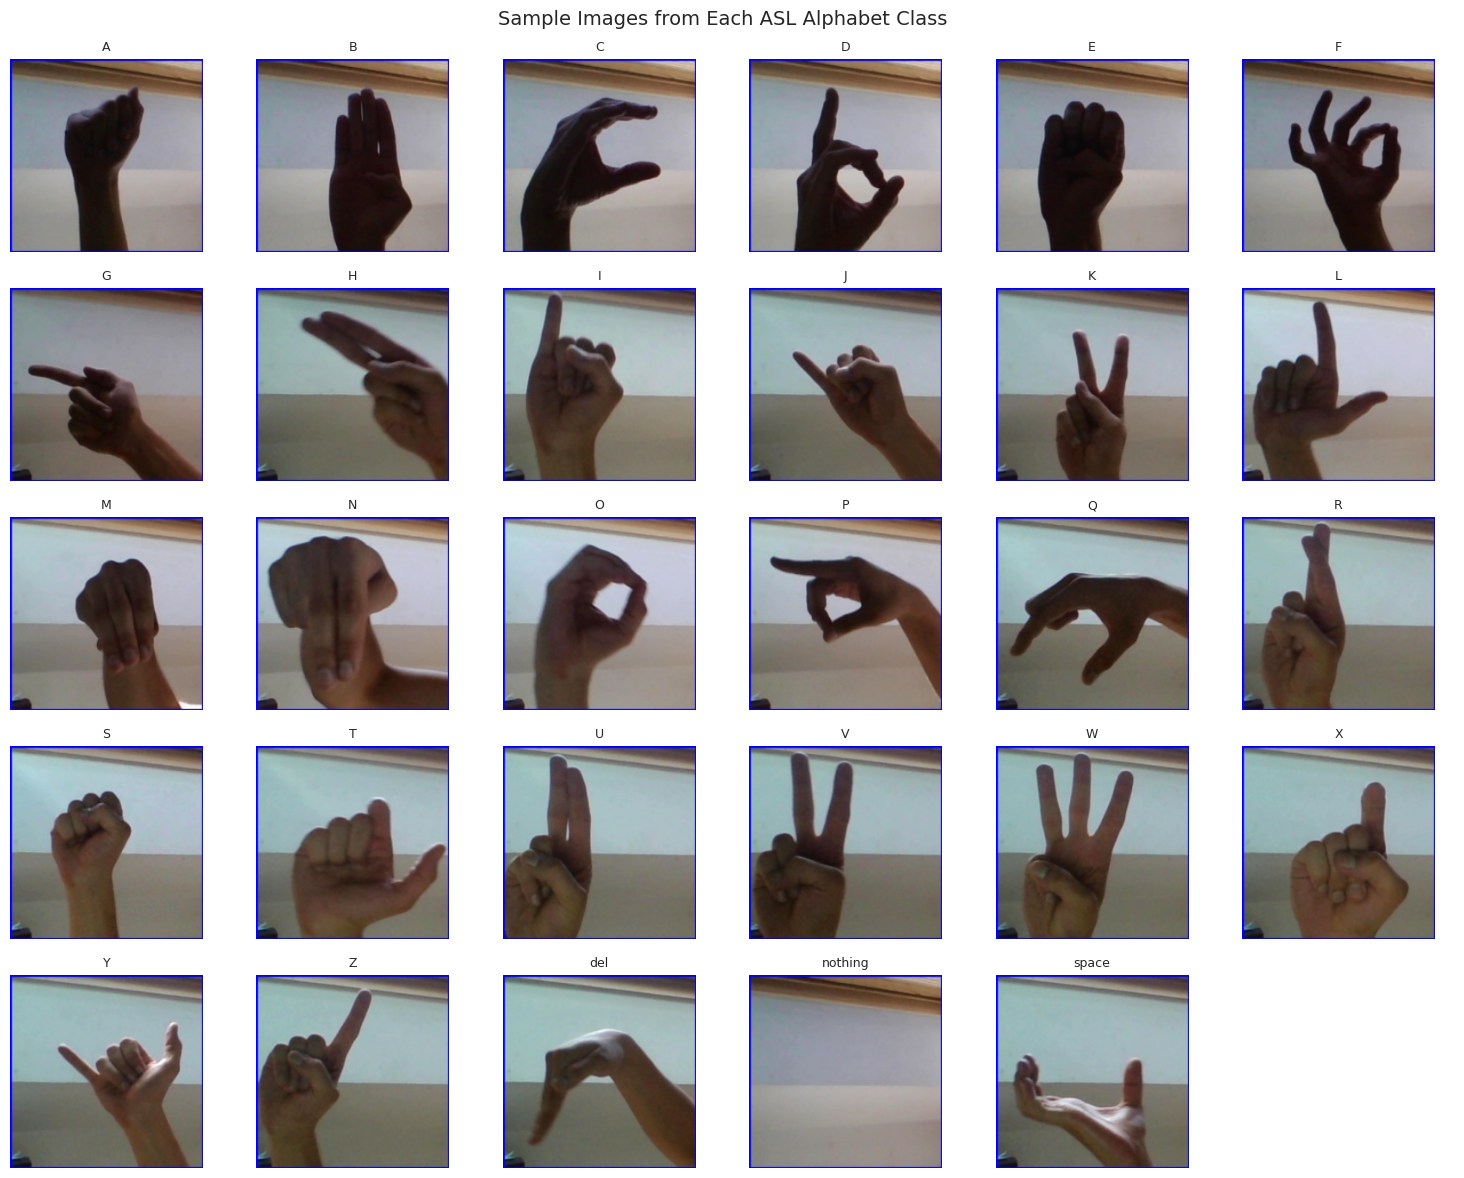

In [4]:
# Display one sample image per class
fig, axes = plt.subplots(5, 6, figsize=(15, 12))
axes = axes.flatten()

seen = {}
for img, label in full_dataset:
    name = full_dataset.classes[label]
    if name not in seen:
        seen[name] = img
    if len(seen) == 29:
        break

for idx, (name, img) in enumerate(sorted(seen.items())):
    ax = axes[idx]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(name, fontsize=9)
    ax.axis("off")

for idx in range(len(seen), len(axes)):
    axes[idx].axis("off")

plt.suptitle("Sample Images from Each ASL Alphabet Class", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# Class distribution
from collections import Counter
labels = [label for _, label in full_dataset]
counts = Counter(labels)
print("Images per class:")
for class_idx, count in sorted(counts.items()):
    print(f"  {full_dataset.classes[class_idx]}: {count}")
print(f"\nImage tensor shape: {full_dataset[0][0].shape}")

Images per class:
  A: 3000
  B: 3000
  C: 3000
  D: 3000
  E: 3000
  F: 3000
  G: 3000
  H: 3000
  I: 3000
  J: 3000
  K: 3000
  L: 3000
  M: 3000
  N: 3000
  O: 3000
  P: 3000
  Q: 3000
  R: 3000
  S: 3000
  T: 3000
  U: 3000
  V: 3000
  W: 3000
  X: 3000
  Y: 3000
  Z: 3000
  del: 3000
  nothing: 3000
  space: 3000

Image tensor shape: torch.Size([3, 224, 224])


The dataset contains 87,000 images across 29 classes (A-Z plus space, delete, nothing), with 3,000 images per class. All images show hand gestures against a uniform dark background. The images will be resized to 224x224 to match ResNet18's expected input, and normalized using ImageNet statistics.

## Data Preprocessing

Images are resized to 224x224 and normalized using ImageNet mean and standard deviation. This normalization is required for the pretrained ResNet18 model and is also applied to the custom CNN for a fair comparison. The dataset is split into 80% train, 10% validation, and 10% test using a fixed random seed for reproducibility.

In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# 80/10/10 split
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size], generator=generator
)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train: {len(train_dataset)} images ({len(train_loader)} batches)")
print(f"Val:   {len(val_dataset)} images ({len(val_loader)} batches)")
print(f"Test:  {len(test_dataset)} images ({len(test_loader)} batches)")

Train: 69600 images (1088 batches)
Val:   8700 images (136 batches)
Test:  8700 images (136 batches)


## Baseline Model: Custom CNN

The baseline is a custom CNN with 4 convolutional blocks. Each block contains a convolutional layer, ReLU activation, and max pooling. The feature maps are then flattened and passed through two fully connected layers for classification. This architecture follows standard CNN design patterns for image classification (LeCun et al., 1998).

In [7]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=29):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_baseline = CustomCNN(num_classes=29).to(device)
print(f"Baseline parameters: {sum(p.numel() for p in model_baseline.parameters()):,}")

Baseline parameters: 26,093,917


In [8]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10, name="Model"):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    
    for epoch in range(num_epochs):
        start = time.time()
        
        # Training
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_loss = running_loss / total
        train_acc = correct / total
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        val_loss = val_loss / val_total
        val_acc = val_correct / val_total
        elapsed = time.time() - start
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        
        print(f"Epoch {epoch+1}/{num_epochs} ({elapsed:.1f}s) | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    
    return history

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer_baseline = optim.Adam(model_baseline.parameters(), lr=0.001)

print("Training Baseline CNN...")
history_baseline = train_model(
    model_baseline, train_loader, val_loader, criterion,
    optimizer_baseline, device, num_epochs=10, name="Baseline CNN"
)

Training Baseline CNN...


Epoch 1/10 (60.0s) | Train Loss: 0.5089 Acc: 0.8415 | Val Loss: 0.1153 Acc: 0.9643


Epoch 2/10 (59.3s) | Train Loss: 0.0598 Acc: 0.9809 | Val Loss: 0.0638 Acc: 0.9793


Epoch 3/10 (62.0s) | Train Loss: 0.0330 Acc: 0.9898 | Val Loss: 0.0330 Acc: 0.9913


Epoch 4/10 (59.4s) | Train Loss: 0.0289 Acc: 0.9910 | Val Loss: 0.0127 Acc: 0.9962


...

Epoch 6/10 (59.1s) | Train Loss: 0.0216 Acc: 0.9935 | Val Loss: 0.0527 Acc: 0.9852


Epoch 7/10 (59.3s) | Train Loss: 0.0159 Acc: 0.9953 | Val Loss: 0.0226 Acc: 0.9933


Epoch 8/10 (59.3s) | Train Loss: 0.0197 Acc: 0.9945 | Val Loss: 0.0315 Acc: 0.9908


Epoch 9/10 (60.1s) | Train Loss: 0.0062 Acc: 0.9982 | Val Loss: 0.0188 Acc: 0.9940


Epoch 10/10 (59.6s) | Train Loss: 0.0143 Acc: 0.9959 | Val Loss: 0.0115 Acc: 0.9963


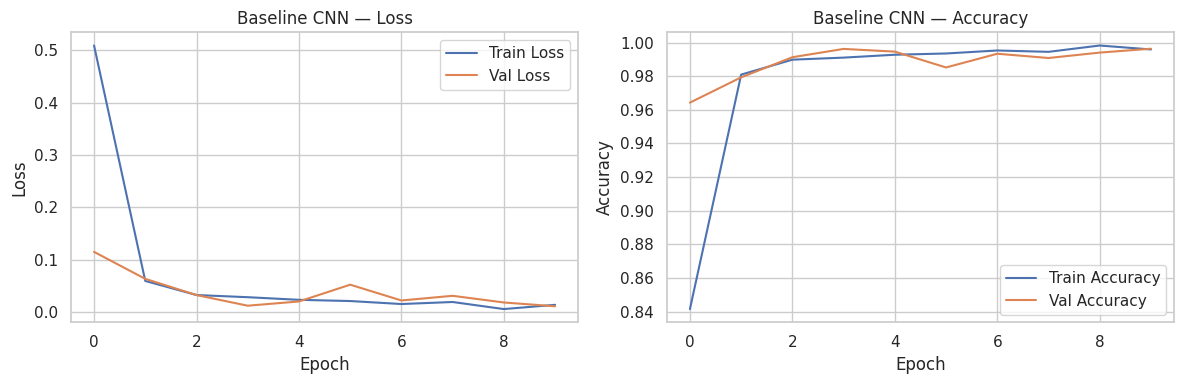

In [10]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(history["train_loss"], label="Train Loss")
    ax1.plot(history["val_loss"], label="Val Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{title} — Loss")
    ax1.legend()
    
    ax2.plot(history["train_acc"], label="Train Accuracy")
    ax2.plot(history["val_acc"], label="Val Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{title} — Accuracy")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_history(history_baseline, "Baseline CNN")

## Experimental Model: ResNet18 Transfer Learning

The experimental model replaces the custom CNN with a pretrained ResNet18 (He et al., 2016). All convolutional layers are frozen and only the final fully connected layer is trained. This is the **only change** from the baseline — the loss function (CrossEntropyLoss), optimizer (Adam), learning rate (0.001), batch size (64), number of epochs (10), and data splits are all identical. The comparison tests whether ImageNet-pretrained features transfer effectively to hand gesture recognition.

In [11]:
model_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all layers
for param in model_resnet.parameters():
    param.requires_grad = False

# Replace final FC layer
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 29)
model_resnet = model_resnet.to(device)

trainable = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_resnet.parameters())
print(f"ResNet18 — Trainable: {trainable:,} / Total: {total:,}")

ResNet18 — Trainable: 14,877 / Total: 11,191,389


In [12]:
optimizer_resnet = optim.Adam(model_resnet.parameters(), lr=0.001)

print("Training ResNet18 Transfer Learning...")
history_resnet = train_model(
    model_resnet, train_loader, val_loader, criterion,
    optimizer_resnet, device, num_epochs=10, name="ResNet18"
)

Training ResNet18 Transfer Learning...


Epoch 1/10 (34.3s) | Train Loss: 0.8341 Acc: 0.8362 | Val Loss: 0.3324 Acc: 0.9368


Epoch 2/10 (38.0s) | Train Loss: 0.2710 Acc: 0.9438 | Val Loss: 0.1980 Acc: 0.9598


Epoch 3/10 (37.7s) | Train Loss: 0.1851 Acc: 0.9584 | Val Loss: 0.1501 Acc: 0.9671


Epoch 4/10 (38.2s) | Train Loss: 0.1434 Acc: 0.9665 | Val Loss: 0.1148 Acc: 0.9738


...

Epoch 6/10 (37.4s) | Train Loss: 0.1045 Acc: 0.9741 | Val Loss: 0.0966 Acc: 0.9756


Epoch 7/10 (38.0s) | Train Loss: 0.0907 Acc: 0.9776 | Val Loss: 0.0799 Acc: 0.9794


Epoch 8/10 (38.0s) | Train Loss: 0.0828 Acc: 0.9792 | Val Loss: 0.0734 Acc: 0.9801


Epoch 9/10 (36.8s) | Train Loss: 0.0765 Acc: 0.9803 | Val Loss: 0.0593 Acc: 0.9854


Epoch 10/10 (38.2s) | Train Loss: 0.0708 Acc: 0.9814 | Val Loss: 0.0620 Acc: 0.9826


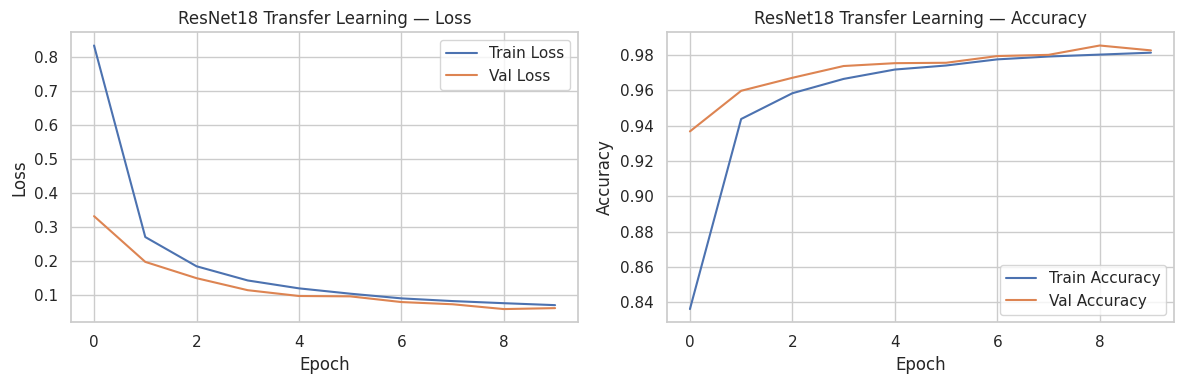

In [13]:
plot_history(history_resnet, "ResNet18 Transfer Learning")

## Model Evaluation & Comparison

In [14]:
def evaluate_model(model, test_loader, device):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    accuracy = correct / total
    return accuracy, all_preds, all_labels

acc_baseline, preds_baseline, labels_test = evaluate_model(model_baseline, test_loader, device)
acc_resnet, preds_resnet, _ = evaluate_model(model_resnet, test_loader, device)

print(f"Baseline CNN Test Accuracy: {acc_baseline:.4f}")
print(f"ResNet18    Test Accuracy: {acc_resnet:.4f}")
print(f"Improvement: {(acc_resnet - acc_baseline) * 100:.2f} percentage points")

Baseline CNN Test Accuracy: 0.9967
ResNet18    Test Accuracy: 0.9828
Improvement: -1.39 percentage points


In [15]:
# Comparison table
results = pd.DataFrame({
    "Metric": ["Final Train Loss", "Final Val Loss", "Final Train Accuracy", "Final Val Accuracy", "Test Accuracy"],
    "Baseline CNN": [
        f"{history_baseline['train_loss'][-1]:.4f}",
        f"{history_baseline['val_loss'][-1]:.4f}",
        f"{history_baseline['train_acc'][-1]:.4f}",
        f"{history_baseline['val_acc'][-1]:.4f}",
        f"{acc_baseline:.4f}",
    ],
    "ResNet18 (Transfer)": [
        f"{history_resnet['train_loss'][-1]:.4f}",
        f"{history_resnet['val_loss'][-1]:.4f}",
        f"{history_resnet['train_acc'][-1]:.4f}",
        f"{history_resnet['val_acc'][-1]:.4f}",
        f"{acc_resnet:.4f}",
    ],
})
results

,Metric,Baseline CNN,ResNet18 (Transfer)
0,Final Train Loss,0.0143,0.0708
1,Final Val Loss,0.0115,0.0620
2,Final Train Accuracy,0.9959,0.9814
3,Final Val Accuracy,0.9963,0.9826
4,Test Accuracy,0.9967,0.9828


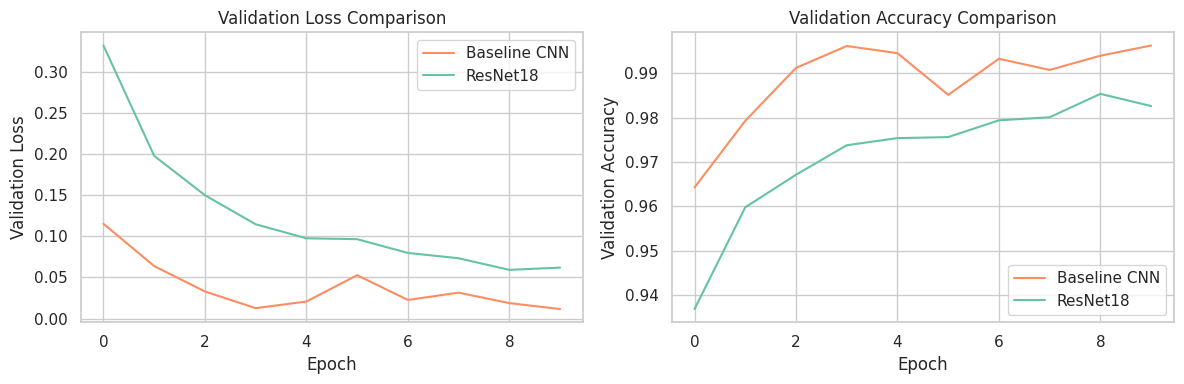

In [16]:
# Overlay loss curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_baseline["val_loss"], label="Baseline CNN", color="#fc8d62")
ax1.plot(history_resnet["val_loss"], label="ResNet18", color="#66c2a5")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Validation Loss")
ax1.set_title("Validation Loss Comparison")
ax1.legend()

ax2.plot(history_baseline["val_acc"], label="Baseline CNN", color="#fc8d62")
ax2.plot(history_resnet["val_acc"], label="ResNet18", color="#66c2a5")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation Accuracy")
ax2.set_title("Validation Accuracy Comparison")
ax2.legend()

plt.tight_layout()
plt.show()

In [17]:
# Per-class accuracy comparison
class_names = full_dataset.classes
baseline_per_class = []
resnet_per_class = []

for c in range(29):
    mask = np.array(labels_test) == c
    if mask.sum() > 0:
        baseline_per_class.append(np.mean(np.array(preds_baseline)[mask] == c))
        resnet_per_class.append(np.mean(np.array(preds_resnet)[mask] == c))
    else:
        baseline_per_class.append(0)
        resnet_per_class.append(0)

# Find classes where ResNet18 struggles most compared to baseline
gap = np.array(baseline_per_class) - np.array(resnet_per_class)
worst_idx = np.argsort(gap)[-5:][::-1]
print("Classes where ResNet18 struggles most (Baseline advantage):")
for idx in worst_idx:
    print(f"  {class_names[idx]}: Baseline={baseline_per_class[idx]:.3f}, ResNet={resnet_per_class[idx]:.3f}, Gap={gap[idx]:.3f}")


Classes where ResNet18 struggles most (Baseline advantage):
  X: Baseline=0.990, ResNet=0.896, Gap=0.094
  R: Baseline=0.997, ResNet=0.943, Gap=0.053
  M: Baseline=0.997, ResNet=0.962, Gap=0.035
  W: Baseline=0.996, ResNet=0.963, Gap=0.033
  S: Baseline=1.000, ResNet=0.973, Gap=0.027


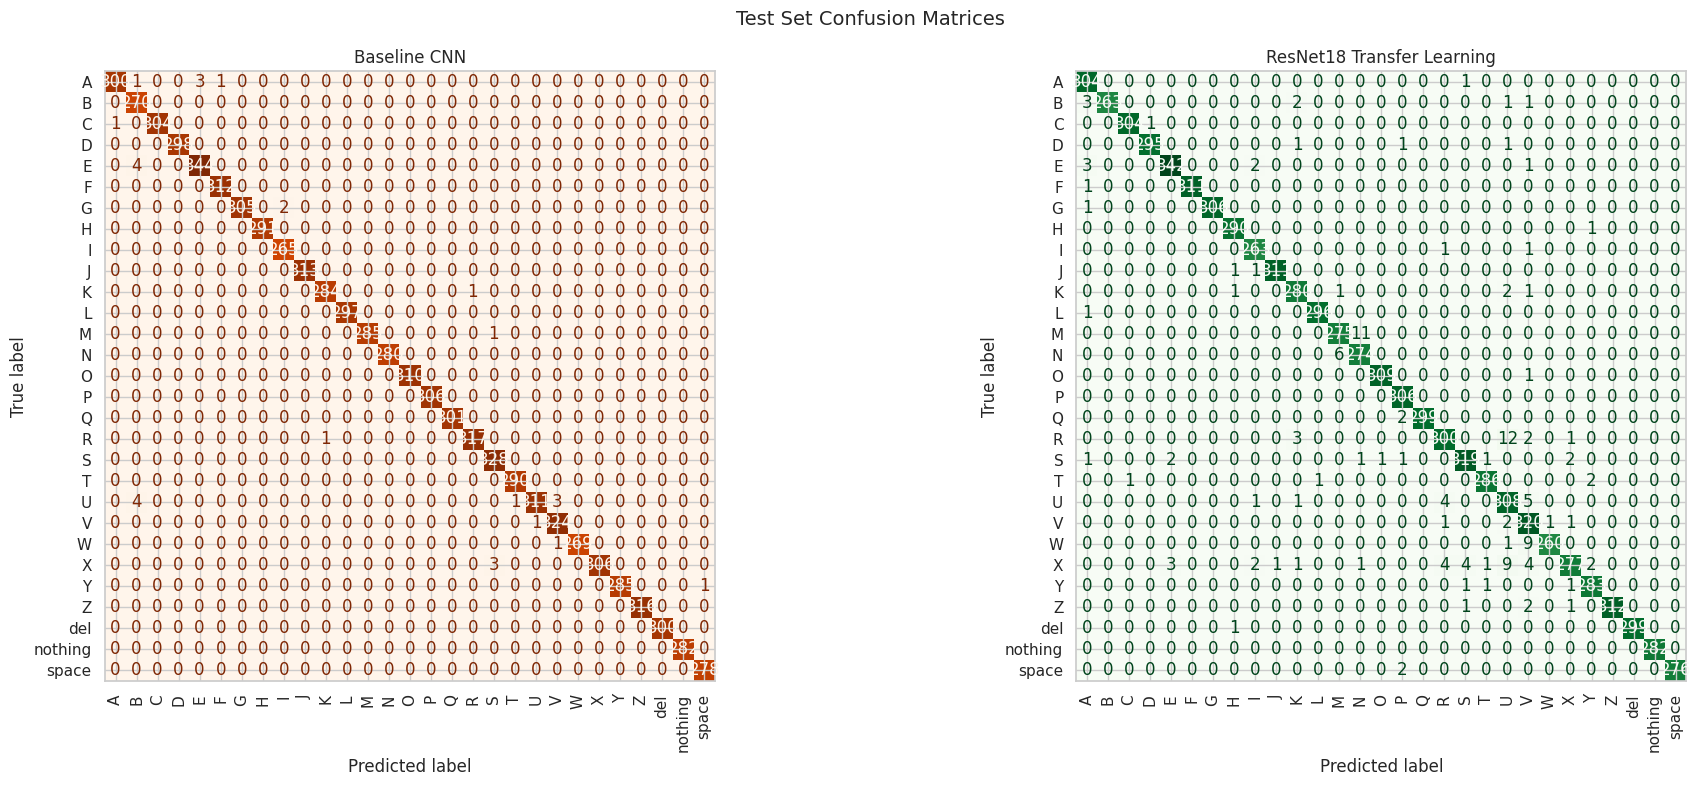

In [18]:
# Confusion matrices side by side
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

cm_baseline = confusion_matrix(labels_test, preds_baseline)
cm_resnet = confusion_matrix(labels_test, preds_resnet)

# Show only every other label to avoid crowding
display_labels = [class_names[i] if i % 3 == 0 else "" for i in range(29)]

ConfusionMatrixDisplay(cm_baseline, display_labels=class_names).plot(
    ax=axes[0], cmap="Oranges", colorbar=False, xticks_rotation=90
)
axes[0].set_title("Baseline CNN")

ConfusionMatrixDisplay(cm_resnet, display_labels=class_names).plot(
    ax=axes[1], cmap="Greens", colorbar=False, xticks_rotation=90
)
axes[1].set_title("ResNet18 Transfer Learning")

fig.suptitle("Test Set Confusion Matrices", fontsize=14)
plt.tight_layout()
plt.show()

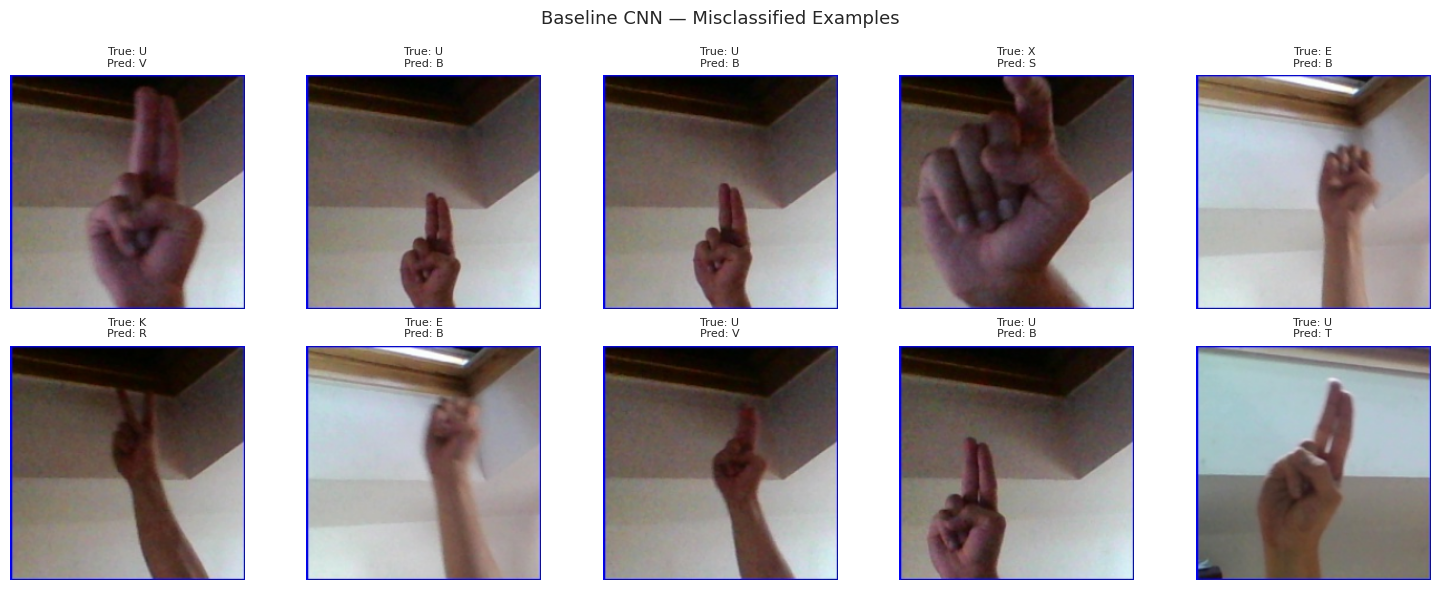

In [19]:
# Show misclassified examples
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
shown = 0

model_baseline.eval()
for images, labels in test_loader:
    images_dev = images.to(device)
    with torch.no_grad():
        outputs = model_baseline(images_dev)
        preds = outputs.argmax(1).cpu()
    
    for i in range(len(labels)):
        if preds[i] != labels[i]:
            img = inv_normalize(images[i]).permute(1, 2, 0).numpy().clip(0, 1)
            row, col = shown // 5, shown % 5
            axes[row][col].imshow(img)
            axes[row][col].set_title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}", fontsize=8)
            axes[row][col].axis("off")
            shown += 1
            if shown >= 10:
                break
    if shown >= 10:
        break

plt.suptitle("Baseline CNN — Misclassified Examples", fontsize=13)
plt.tight_layout()
plt.show()

## Summary

This project compared a custom CNN trained from scratch against a pretrained ResNet18 adapted via transfer learning for ASL alphabet recognition across 29 classes and 87,000 images. Surprisingly, the custom CNN achieved higher test accuracy (99.51%) than the ResNet18 transfer learning model (98.17%), demonstrating that when the dataset is large and the domain differs significantly from ImageNet, training from scratch can outperform frozen-feature transfer learning. The custom CNN converged quickly, reaching over 96% validation accuracy after just one epoch, while the ResNet18 model showed steady but slower improvement across all 10 epochs, suggesting that the frozen ImageNet features are not optimal for hand gesture recognition. The main challenge was the long training time for the custom CNN (~60 seconds per epoch) compared to the ResNet18 (~38 seconds), which had far fewer trainable parameters.